In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score,roc_curve

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [90]:
pd.set_option('display.max_columns', None)

In [91]:
df = pd.read_csv('record.csv')
df.head()

,ID,INV_UNIQUE,INV_TYPE,INV_INVOICE_NO,INV_CREATED,INV_UPDATED,INV_CREATED_DATE,INV_INVOICE_DATE,CUSTOMER_ACCOUNT_CODE,CUSTOMER_NAME,PMA_PART_ONLY,FULL_DESC,INV_QTY,INV_NETT_PRICE,INV_NETT_VALUE,PARAM_1,AC,SALES_REP,GROSS_PROFIT,PARAM_2,PARAM_3,INV_CURRENCY,INV_CURR_CONVERSION,PARAM_4,OBJECTS,GBP_TOTALSALES,ORDER_NUMBER_TEXT,INV_CURR_RATE,INV_ORDER_TYPE,INV_PAY_TERMS,INV_CREATED_BY,INV_VAT_CODE,INV_VAT_PERCENT,INV_VAT_VALUE,PMA_ANAL_FIELD10,PMA_ANAL_FIELD1,PMA_ANAL_FIELD2,PMA_ANAL_FIELD3,PMA_WEIGHT,INV_NETT_PRI_H_PER,INV_NETT_PRI_H,INV_VAT_VAL_H,INV_GROSS_VALUE,COST_PRICE,SELL_PRICE,INV_NETT_PRICE_PER,REC_FROM,DATA_OF_YEAR,CREATEDDATE,MODIFYDATE,CATEGORY_ID,BRAND_ID,InvRow,OKFlag,Reason,GROSS_PMA_WEIGHT,ORD_PRICE
0,3343762,NaN,I,530868,NaN,NaN,2022-01-03 00:00:00.000,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,22026.0,Humza Veg Samosa 10x650g(20 pieces),1.0,27.99,27.99,NaN,NaN,SAS,17.23,NaN,NaN,GBP,NaN,NaN,NaN,27.99,527099,1.0,SBIR,30,NaN,Z,0,0.0,Humza,South Asian,Frozen,Samosa,6.5,NaN,27.99,0.0,27.99,10.76,27.99,NaN,hansa,2022,2022-01-03 10:01:10.883,2022-02-25 10:00:59.740,12.0,462.0,530868-0,1,NaN,7.120,0.0
1,3343763,NaN,I,530868,NaN,NaN,2022-01-03 00:00:00.000,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,22596.0,Surya Frozen Cassava Chips 6x1kg,5.0,9.99,49.95,NaN,NaN,SAS,6.55,NaN,NaN,GBP,NaN,NaN,NaN,49.95,527099,1.0,SBIR,30,NaN,Z,0,0.0,Surya,South Asian,Frozen,Cassava,6.0,NaN,9.99,0.0,49.95,8.68,9.99,NaN,hansa,2022,2022-01-03 10:01:10.883,2022-02-25 10:00:59.740,12.0,529.0,530868-1,1,NaN,31.950,0.0
2,3343764,NaN,I,530868,NaN,NaN,2022-01-03 00:00:00.000,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,23023.0,Switz Spring Rolls Pastry 30x550G (10x10),1.0,27.19,27.19,NaN,NaN,SAS,3.84,NaN,NaN,GBP,NaN,NaN,NaN,27.19,527099,1.0,SBIR,30,NaN,Z,0,0.0,Switz,South Asian,Frozen,Pastry Dough,16.5,NaN,27.19,0.0,27.19,23.35,27.19,NaN,hansa,2022,2022-01-03 10:01:10.883,2022-02-25 10:00:59.740,12.0,532.0,530868-2,1,NaN,20.070,0.0
3,3343765,NaN,I,530868,NaN,NaN,2022-01-03 00:00:00.000,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,23457.0,Humza Lahori Chicken Charcoal Seekh Kebab 8x900g,1.0,39.36,39.36,NaN,NaN,SAS,16.69,NaN,NaN,GBP,NaN,NaN,NaN,39.36,527099,1.0,SBIR,30,NaN,Z,0,0.0,Humza,South Asian,Frozen,House Lines,7.2,NaN,39.36,0.0,39.36,22.67,39.36,NaN,hansa,2022,2022-01-03 10:01:10.883,2022-02-25 10:00:59.740,12.0,462.0,530868-3,1,NaN,7.810,0.0
4,3343766,NaN,I,530868,NaN,NaN,2022-01-03 00:00:00.000,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,25456.0,Shazans Methi 12x300g,1.0,8.74,8.74,NaN,NaN,SAS,1.47,NaN,NaN,GBP,NaN,NaN,NaN,8.74,527099,1.0,SBIR,30,NaN,Z,0,0.0,Shazan,South Asian,Frozen,No Analysis,3.6,NaN,8.74,0.0,8.74,7.27,8.74,NaN,hansa,2022,2022-01-03 10:01:10.883,2022-02-25 10:00:59.740,12.0,524.0,530868-4,1,NaN,3.852,0.0


In [5]:
df.columns

Index(['ID', 'INV_UNIQUE', 'INV_TYPE', 'INV_INVOICE_NO', 'INV_CREATED',
       'INV_UPDATED', 'INV_CREATED_DATE', 'INV_INVOICE_DATE',
       'CUSTOMER_ACCOUNT_CODE', 'CUSTOMER_NAME', 'PMA_PART_ONLY', 'FULL_DESC',
       'INV_QTY', 'INV_NETT_PRICE', 'INV_NETT_VALUE', 'PARAM_1', 'AC',
       'SALES_REP', 'GROSS_PROFIT', 'PARAM_2', 'PARAM_3', 'INV_CURRENCY',
       'INV_CURR_CONVERSION', 'PARAM_4', 'OBJECTS', 'GBP_TOTALSALES',
       'ORDER_NUMBER_TEXT', 'INV_CURR_RATE', 'INV_ORDER_TYPE', 'INV_PAY_TERMS',
       'INV_CREATED_BY', 'INV_VAT_CODE', 'INV_VAT_PERCENT', 'INV_VAT_VALUE',
       'PMA_ANAL_FIELD10', 'PMA_ANAL_FIELD1', 'PMA_ANAL_FIELD2',
       'PMA_ANAL_FIELD3', 'PMA_WEIGHT', 'INV_NETT_PRI_H_PER', 'INV_NETT_PRI_H',
       'INV_VAT_VAL_H', 'INV_GROSS_VALUE', 'COST_PRICE', 'SELL_PRICE',
       'INV_NETT_PRICE_PER', 'REC_FROM', 'DATA_OF_YEAR', 'CREATEDDATE',
       'MODIFYDATE', 'CATEGORY_ID', 'BRAND_ID', 'InvRow', 'OKFlag', 'Reason',
       'GROSS_PMA_WEIGHT', 'ORD_PRICE'],
      dt

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844180 entries, 0 to 844179
Data columns (total 57 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     844180 non-null  int64  
 1   INV_UNIQUE             0 non-null       float64
 2   INV_TYPE               844180 non-null  object 
 3   INV_INVOICE_NO         844180 non-null  int64  
 4   INV_CREATED            0 non-null       float64
 5   INV_UPDATED            0 non-null       float64
 6   INV_CREATED_DATE       844180 non-null  object 
 7   INV_INVOICE_DATE       844180 non-null  object 
 8   CUSTOMER_ACCOUNT_CODE  844180 non-null  int64  
 9   CUSTOMER_NAME          844109 non-null  object 
 10  PMA_PART_ONLY          826270 non-null  float64
 11  FULL_DESC              832633 non-null  object 
 12  INV_QTY                844180 non-null  float64
 13  INV_NETT_PRICE         844180 non-null  float64
 14  INV_NETT_VALUE         844180 non-nu

In [7]:
# Show all the columns
pd.set_option('display.max_columns', None)

In [8]:
print(df.columns.tolist())

['ID', 'INV_UNIQUE', 'INV_TYPE', 'INV_INVOICE_NO', 'INV_CREATED', 'INV_UPDATED', 'INV_CREATED_DATE', 'INV_INVOICE_DATE', 'CUSTOMER_ACCOUNT_CODE', 'CUSTOMER_NAME', 'PMA_PART_ONLY', 'FULL_DESC', 'INV_QTY', 'INV_NETT_PRICE', 'INV_NETT_VALUE', 'PARAM_1', 'AC', 'SALES_REP', 'GROSS_PROFIT', 'PARAM_2', 'PARAM_3', 'INV_CURRENCY', 'INV_CURR_CONVERSION', 'PARAM_4', 'OBJECTS', 'GBP_TOTALSALES', 'ORDER_NUMBER_TEXT', 'INV_CURR_RATE', 'INV_ORDER_TYPE', 'INV_PAY_TERMS', 'INV_CREATED_BY', 'INV_VAT_CODE', 'INV_VAT_PERCENT', 'INV_VAT_VALUE', 'PMA_ANAL_FIELD10', 'PMA_ANAL_FIELD1', 'PMA_ANAL_FIELD2', 'PMA_ANAL_FIELD3', 'PMA_WEIGHT', 'INV_NETT_PRI_H_PER', 'INV_NETT_PRI_H', 'INV_VAT_VAL_H', 'INV_GROSS_VALUE', 'COST_PRICE', 'SELL_PRICE', 'INV_NETT_PRICE_PER', 'REC_FROM', 'DATA_OF_YEAR', 'CREATEDDATE', 'MODIFYDATE', 'CATEGORY_ID', 'BRAND_ID', 'InvRow', 'OKFlag', 'Reason', 'GROSS_PMA_WEIGHT', 'ORD_PRICE']


In [92]:
cleaned_df = df.drop(columns=['INV_CREATED', 'INV_UPDATED', 'PARAM_2', 'PARAM_3', 'INV_CURR_CONVERSION', 
                              'PARAM_4', 'OBJECTS', 'INV_CURR_RATE', 'INV_ORDER_TYPE', 'INV_PAY_TERMS', 
                              'INV_VAT_CODE', 'INV_VAT_PERCENT', 'INV_VAT_VALUE', 'PMA_WEIGHT', 
                              'INV_NETT_PRI_H_PER', 'INV_NETT_PRI_H', 'INV_VAT_VAL_H', 'INV_GROSS_VALUE', 
                              'INV_NETT_PRICE_PER', 'CREATEDDATE', 'MODIFYDATE','OKFlag', 
                              'Reason', 'GROSS_PMA_WEIGHT', 'ORD_PRICE'],axis = 1,errors = "ignore")

In [93]:
cleaned_df.shape

(844180, 32)

In [94]:
cleaned_df.columns

Index(['ID', 'INV_UNIQUE', 'INV_TYPE', 'INV_INVOICE_NO', 'INV_CREATED_DATE',
       'INV_INVOICE_DATE', 'CUSTOMER_ACCOUNT_CODE', 'CUSTOMER_NAME',
       'PMA_PART_ONLY', 'FULL_DESC', 'INV_QTY', 'INV_NETT_PRICE',
       'INV_NETT_VALUE', 'PARAM_1', 'AC', 'SALES_REP', 'GROSS_PROFIT',
       'INV_CURRENCY', 'GBP_TOTALSALES', 'ORDER_NUMBER_TEXT', 'INV_CREATED_BY',
       'PMA_ANAL_FIELD10', 'PMA_ANAL_FIELD1', 'PMA_ANAL_FIELD2',
       'PMA_ANAL_FIELD3', 'COST_PRICE', 'SELL_PRICE', 'REC_FROM',
       'DATA_OF_YEAR', 'CATEGORY_ID', 'BRAND_ID', 'InvRow'],
      dtype='object')

In [95]:
cleaned_df = cleaned_df.drop(columns = ['INV_UNIQUE','INV_INVOICE_DATE','INV_CREATED_BY','PARAM_1','AC'],axis=1)

In [96]:
cleaned_df.head(2)

,ID,INV_TYPE,INV_INVOICE_NO,INV_CREATED_DATE,CUSTOMER_ACCOUNT_CODE,CUSTOMER_NAME,PMA_PART_ONLY,FULL_DESC,INV_QTY,INV_NETT_PRICE,INV_NETT_VALUE,SALES_REP,GROSS_PROFIT,INV_CURRENCY,GBP_TOTALSALES,ORDER_NUMBER_TEXT,PMA_ANAL_FIELD10,PMA_ANAL_FIELD1,PMA_ANAL_FIELD2,PMA_ANAL_FIELD3,COST_PRICE,SELL_PRICE,REC_FROM,DATA_OF_YEAR,CATEGORY_ID,BRAND_ID,InvRow
0,3343762,I,530868,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,22026.0,Humza Veg Samosa 10x650g(20 pieces),1.0,27.99,27.99,SAS,17.23,GBP,27.99,527099,Humza,South Asian,Frozen,Samosa,10.76,27.99,hansa,2022,12.0,462.0,530868-0
1,3343763,I,530868,2022-01-03 00:00:00.000,117943,Raja Exotics Ltd,22596.0,Surya Frozen Cassava Chips 6x1kg,5.0,9.99,49.95,SAS,6.55,GBP,49.95,527099,Surya,South Asian,Frozen,Cassava,8.68,9.99,hansa,2022,12.0,529.0,530868-1


In [97]:
cleaned_df = cleaned_df.rename(columns={
    'INV_INVOICE_NO': 'INVOICE_NO',
    'CUSTOMER_ACCOUNT_CODE': 'CUSTOMER_ID',
    'PMA_PART_ONLY': 'PRODUCT_CODE',
    'FULL_DESC' : 'PRODUCT_DESC',
    'INV_QTY' : 'QUANTITY',
    'INV_NETT_PRICE' : 'NETT_PRICE',
    'INV_NETT_VALUE' : 'NETT_VALUE',
    'PMA_ANAL_FIELD10' : 'BRAND_NAME',
    'PMA_ANAL_FIELD1' : 'REGION',
    'PMA_ANAL_FIELD2' : 'PRODUCT_TYPE',
    'PMA_ANAL_FIELD3' : 'PRODUCT'   
})

In [98]:
cleaned_df = cleaned_df[cleaned_df['INV_TYPE'] == 'I']

In [99]:
print(cleaned_df.columns.tolist())

['ID', 'INV_TYPE', 'INVOICE_NO', 'INV_CREATED_DATE', 'CUSTOMER_ID', 'CUSTOMER_NAME', 'PRODUCT_CODE', 'PRODUCT_DESC', 'QUANTITY', 'NETT_PRICE', 'NETT_VALUE', 'SALES_REP', 'GROSS_PROFIT', 'INV_CURRENCY', 'GBP_TOTALSALES', 'ORDER_NUMBER_TEXT', 'BRAND_NAME', 'REGION', 'PRODUCT_TYPE', 'PRODUCT', 'COST_PRICE', 'SELL_PRICE', 'REC_FROM', 'DATA_OF_YEAR', 'CATEGORY_ID', 'BRAND_ID', 'InvRow']


In [100]:
cleaned_df['order_date'] = pd.to_datetime(cleaned_df['INV_CREATED_DATE'])
cleaned_df['order_date'].head()

0   2022-01-03
1   2022-01-03
2   2022-01-03
3   2022-01-03
4   2022-01-03
Name: order_date, dtype: datetime64[ns]

In [101]:
cleaned_df['order_day'] = cleaned_df['order_date'].dt.day
cleaned_df['order_month'] = cleaned_df['order_date'].dt.month
cleaned_df['order_year'] = cleaned_df['order_date'].dt.year

In [102]:
numeric_df = cleaned_df.select_dtypes(include=["int64","float64"])
numeric_df.head(2)

,ID,INVOICE_NO,CUSTOMER_ID,PRODUCT_CODE,QUANTITY,NETT_PRICE,NETT_VALUE,GROSS_PROFIT,GBP_TOTALSALES,ORDER_NUMBER_TEXT,COST_PRICE,SELL_PRICE,DATA_OF_YEAR,CATEGORY_ID,BRAND_ID
0,3343762,530868,117943,22026.0,1.0,27.99,27.99,17.23,27.99,527099,10.76,27.99,2022,12.0,462.0
1,3343763,530868,117943,22596.0,5.0,9.99,49.95,6.55,49.95,527099,8.68,9.99,2022,12.0,529.0


In [103]:
correlation_matrix = numeric_df.corr()

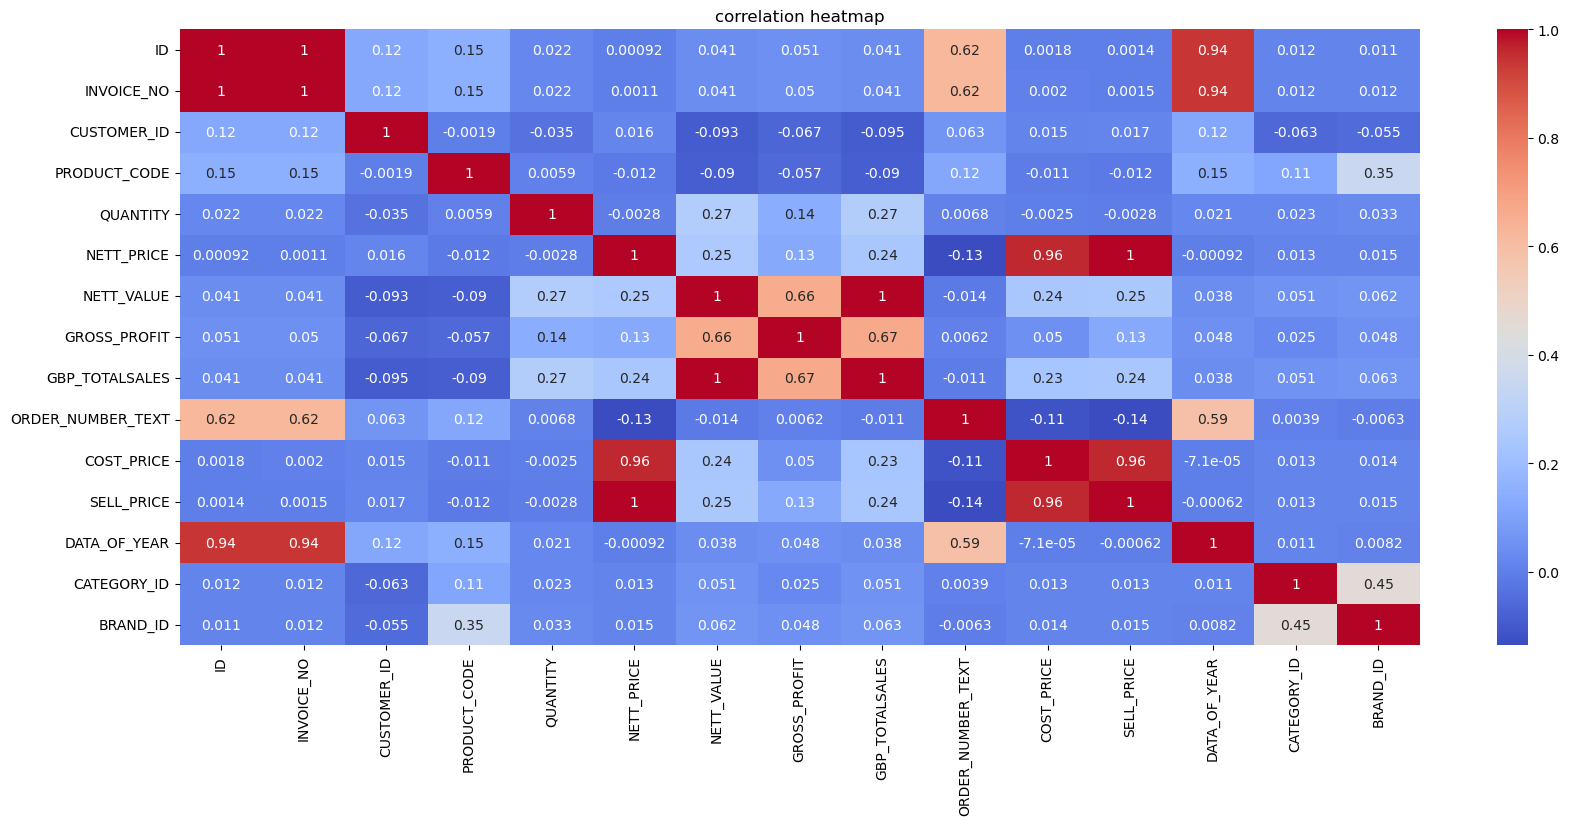

In [104]:
plt.figure(figsize=(20,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title("correlation heatmap")
plt.show()

# Customer Order on the basis of year and month

In [22]:
repetitive_customer = cleaned_df.groupby(['CUSTOMER_ID', 'order_year', 'order_month']) \
                         .size().reset_index(name='sales_count')
repetitive_customer

,CUSTOMER_ID,order_year,order_month,sales_count
0,100006,2022,1,44
1,100006,2022,3,49
2,100006,2022,8,53
3,100006,2022,10,55
4,100006,2023,1,44
...,...,...,...,...
27516,177469,2024,12,32
27517,177472,2024,12,1
27518,177473,2024,12,6
27519,177475,2024,12,12


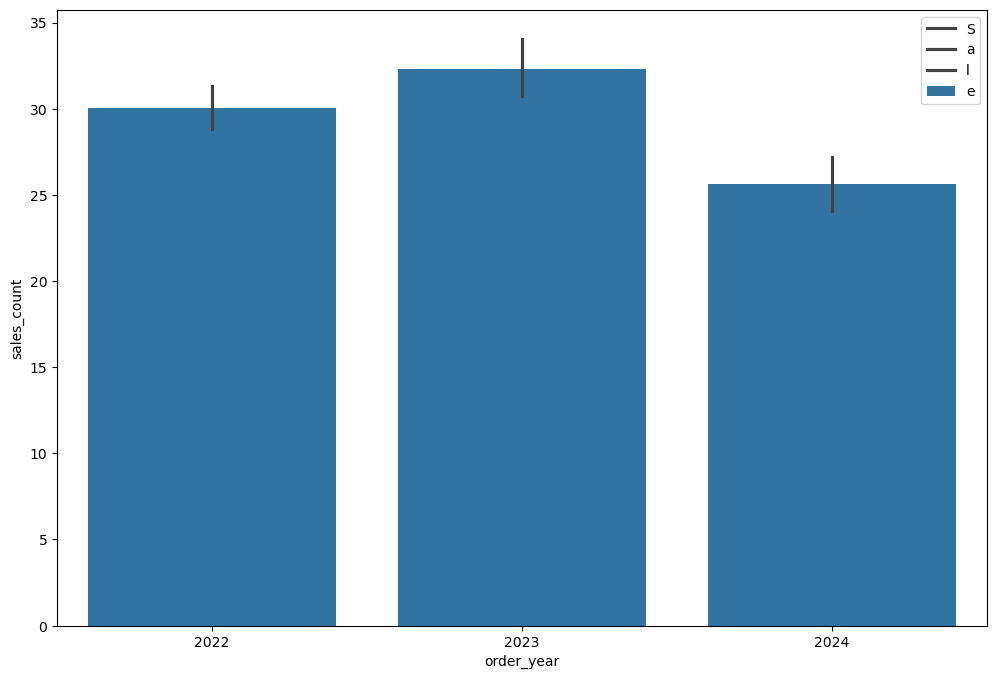

In [28]:
plt.figure(figsize=(12,8))
sns.barplot(x='order_year', y='sales_count', data=repetitive_customer, label='Sales Count')
plt.legend('Sales Count')
plt.show()

In [32]:
# Assuming cleaned_df is already loaded with 'order_date' parsed as datetime
cleaned_df = cleaned_df.sort_values(by=['CUSTOMER_ID', 'order_date'])

# Count number of unique order dates per customer
order_counts = (
    cleaned_df.groupby('CUSTOMER_ID')['order_date']
    .nunique()
    .reset_index()
    .rename(columns={'order_date': 'num_orders'})
)

# Flag customers with more than 2 unique order dates as repetitive
order_counts['Repetitive_Customer'] = order_counts['num_orders'] > 2

# Merge flag back to cleaned_df
cleaned_df = cleaned_df.merge(
    order_counts[['CUSTOMER_ID', 'Repetitive_Customer']],
    on='CUSTOMER_ID',
    how='left'
)

# Flag customers who ordered at least twice within 30 days
def check_within_30_days(dates):
    dates = sorted(dates)
    for i in range(len(dates) - 1):
        if (dates[i+1] - dates[i]).days <= 30:
            return True
    return False

within_30 = (
    cleaned_df.groupby('CUSTOMER_ID')['order_date']
    .apply(check_within_30_days)
    .reset_index()
    .rename(columns={'order_date': 'Repetitive_Within_30_Days'})
)

cleaned_df = cleaned_df.merge(within_30, on='CUSTOMER_ID', how='left')


In [33]:
cleaned_df

,ID,INV_TYPE,INVOICE_NO,INV_CREATED_DATE,CUSTOMER_ID,CUSTOMER_NAME,PRODUCT_CODE,PRODUCT_DESC,QUANTITY,NETT_PRICE,NETT_VALUE,SALES_REP,GROSS_PROFIT,INV_CURRENCY,GBP_TOTALSALES,ORDER_NUMBER_TEXT,BRAND_NAME,REGION,PRODUCT_TYPE,PRODUCT,COST_PRICE,SELL_PRICE,REC_FROM,DATA_OF_YEAR,BRAND_ID,InvRow,order_date,order_day,order_month,order_year,Repetitive_Customer,Repetitive_Within_30_Days
0,3348131,I,531554,2022-01-10 00:00:00.000,100006,Abu Bakar Freshways (Mr W & Mr A Hussai,11555.0,Costa Blackcurrant Drink6x2L,1.0,3.84,3.84,ADW,0.55,GBP,3.84,526967,Costa,Polish,Beverages,Juice,3.29,3.84,hansa,2022,317.0,531554-0,2022-01-10,10,1,2022,True,True
1,3348132,I,531554,2022-01-10 00:00:00.000,100006,Abu Bakar Freshways (Mr W & Mr A Hussai,13300.0,Wonderfarm Tamarind Drink 24x320ML,1.0,9.89,9.89,ADW,0.78,GBP,9.89,526967,Wonderfarm,South Asian,Beverages,Juice Drink,9.11,9.89,hansa,2022,536.0,531554-4,2022-01-10,10,1,2022,True,True
2,3348133,I,531554,2022-01-10 00:00:00.000,100006,Abu Bakar Freshways (Mr W & Mr A Hussai,16911.0,Mai Thai AAA Jasmine Rice 10KG,20.0,10.57,211.40,ADW,58.40,GBP,211.40,526967,Mai Thai,Oriental,Jasmine Rice,No Analysis,7.65,10.57,hansa,2022,164.0,531554-10,2022-01-10,10,1,2022,True,True
3,3348169,I,531554,2022-01-10 00:00:00.000,100006,Abu Bakar Freshways (Mr W & Mr A Hussai,25950.0,MA Fufu Flour (Plantain) 24x680G,1.0,44.22,44.22,ADW,5.70,GBP,44.22,526967,Mother Africa,African,Flour,No Subgroup,38.52,44.22,hansa,2022,21.0,531554-38,2022-01-10,10,1,2022,True,True
4,3348206,I,531554,2022-01-10 00:00:00.000,100006,Abu Bakar Freshways (Mr W & Mr A Hussai,27038.0,Sales Rep Discount,1.0,-200.00,-200.00,ADW,NaN,GBP,-200.00,526967,No Brand,Other,Packing,Packing,NaN,NaN,hansa,2022,615.0,531554-43,2022-01-10,10,1,2022,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803090,4189376,I,640768,2024-12-30 00:00:00.000,177476,Bourhan,18067.0,Surya 1121 Extra Long Superior Rice 5KG,8.0,9.12,72.96,OL,23.04,GBP,72.96,621682,Surya,South Asian,Rice,Rice - 1121,6.24,9.12,hansa,2024,529.0,640768-4,2024-12-30,30,12,2024,False,True
803091,4189381,I,640768,2024-12-30 00:00:00.000,177476,Bourhan,28795.0,Laila Canned Plum Tomatoes12x400g,1.0,7.33,7.33,OL,1.32,GBP,7.33,621682,Laila,South Asian,Canned Food,Tomato,6.01,7.33,hansa,2024,475.0,640768-16,2024-12-30,30,12,2024,False,True
803092,4189384,I,640768,2024-12-30 00:00:00.000,177476,Bourhan,13662.0,IS Semolina Coarse 10x500G,1.0,7.95,7.95,OL,2.03,GBP,7.95,621682,Island Sun,Caribbean,Flour,Semolina,5.92,7.95,hansa,2024,47.0,640768-3,2024-12-30,30,12,2024,False,True
803093,4189385,I,640768,2024-12-30 00:00:00.000,177476,Bourhan,13656.0,IS Semolina Fine 10x500G,1.0,8.84,8.84,OL,2.92,GBP,8.84,621682,Island Sun,Caribbean,Flour,Semolina,5.92,8.84,hansa,2024,47.0,640768-2,2024-12-30,30,12,2024,False,True


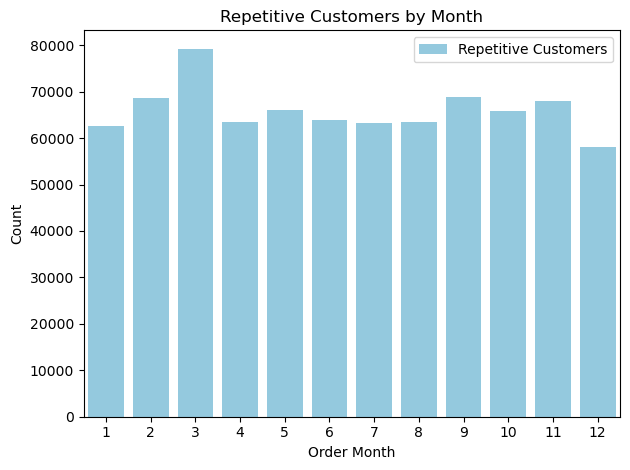

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your DataFrame is named 'df'
# Filter for repetitive customers and count by order_month
rep_cust_counts = cleaned_df[cleaned_df['Repetitive_Customer'] == 1].groupby('order_month')['Repetitive_Customer'].count().reset_index()

rep_cust_counts.columns = ['order_month', 'Repetitive_Customer_Count']

sns.barplot(x='order_month', y='Repetitive_Customer_Count', data=merged_counts, color='skyblue', label='Repetitive Customers')
plt.title('Repetitive Customers by Month')
plt.xlabel('Order Month')
plt.ylabel('Count')
plt.legend()


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [79]:
cleaned_df.columns

Index(['ID', 'INV_TYPE', 'INVOICE_NO', 'INV_CREATED_DATE', 'CUSTOMER_ID',
       'CUSTOMER_NAME', 'PRODUCT_CODE', 'PRODUCT_DESC', 'QUANTITY',
       'NETT_PRICE', 'NETT_VALUE', 'SALES_REP', 'GROSS_PROFIT', 'INV_CURRENCY',
       'GBP_TOTALSALES', 'ORDER_NUMBER_TEXT', 'BRAND_NAME', 'REGION',
       'PRODUCT_TYPE', 'PRODUCT', 'COST_PRICE', 'SELL_PRICE', 'REC_FROM',
       'DATA_OF_YEAR', 'BRAND_ID', 'InvRow', 'order_date', 'order_day',
       'order_month', 'order_year', 'Repetitive_Customer',
       'Repetitive_Within_30_Days'],
      dtype='object')

In [80]:
df.to_csv('cleaned_df.csv',index = False)

In [39]:
cleaned_df['purchase_date_day'] = pd.to_datetime(cleaned_df['order_date']).dt.normalize()

In [40]:
days_per_merchant = cleaned_df.groupby(['CUSTOMER_ID','BRAND_NAME'])['purchase_date_day'].nunique().reset_index()

In [41]:
days_per_merchant.rename(columns ={'purchase_date_day':'num_distinct_purchase_days'}, inplace = True)

In [42]:
day_aggregation = days_per_merchant.groupby('CUSTOMER_ID')['num_distinct_purchase_days'].agg(
    mean_days_per_merchant = 'mean',
    std_days_per_merchant = 'std',
    max_days_per_merchant = 'max',
    median_days_per_merchant = 'median'
).reset_index()

In [43]:
days_per_merchant

,CUSTOMER_ID,BRAND_NAME,num_distinct_purchase_days
0,100006,Apna,12
1,100006,Britannia,5
2,100006,Cawoods,3
3,100006,Cocofresh,2
4,100006,Costa,8
...,...,...,...
32613,177476,Laila,1
32614,177476,No Brand,1
32615,177476,SIAFA,1
32616,177476,Samai,1


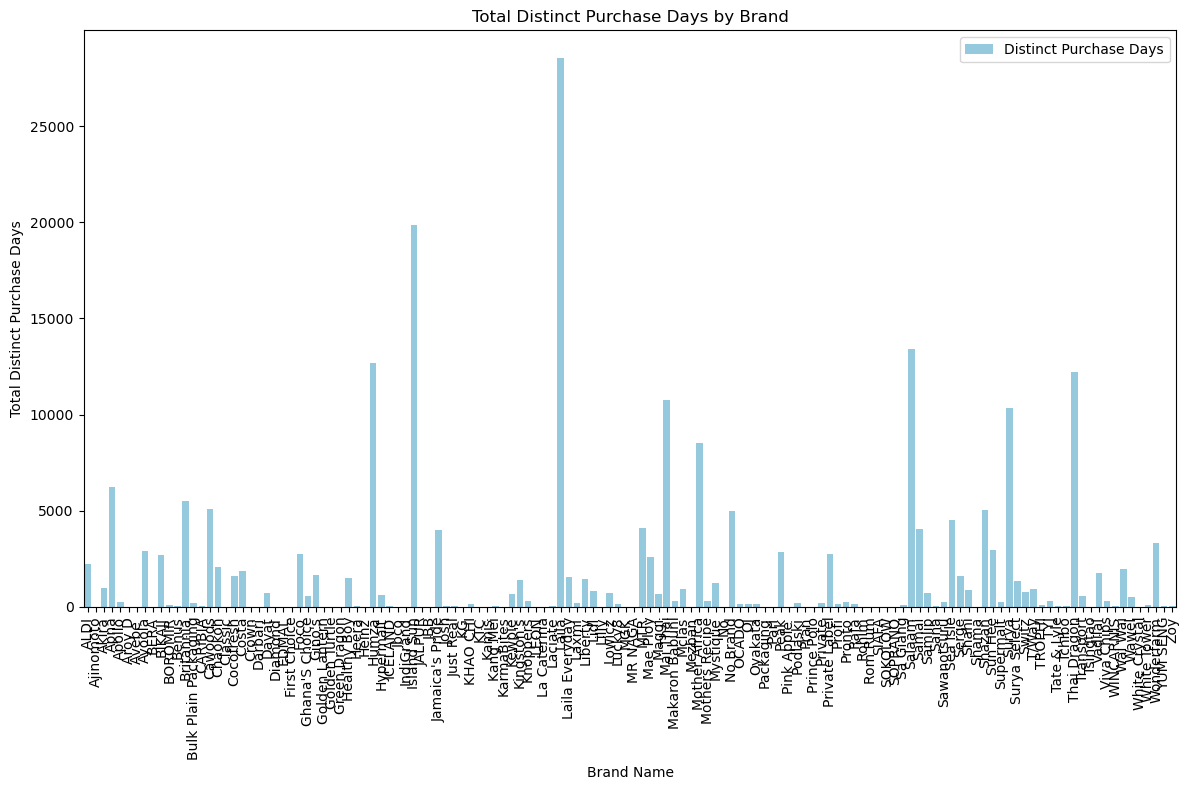

In [48]:
brand_purchase_days = days_per_merchant.groupby('BRAND_NAME')['num_distinct_purchase_days'].sum().reset_index()

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='BRAND_NAME', y='num_distinct_purchase_days', data=brand_purchase_days, color='skyblue', label='Distinct Purchase Days')
plt.title('Total Distinct Purchase Days by Brand')
plt.xlabel('Brand Name')
plt.ylabel('Total Distinct Purchase Days')
#plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.xticks(rotation = 90, ha = 'center')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
day_aggregation

,CUSTOMER_ID,mean_days_per_merchant,std_days_per_merchant,max_days_per_merchant,median_days_per_merchant
0,100006,5.838710,4.465399,14,5.0
1,100007,14.538462,11.739762,41,11.5
2,100011,6.857143,5.992058,17,4.0
3,100022,5.366667,4.521850,14,3.0
4,100024,10.965517,16.530238,70,4.0
...,...,...,...,...,...
2760,177469,1.333333,0.577350,2,1.0
2761,177472,1.000000,NaN,1,1.0
2762,177473,1.000000,0.000000,1,1.0
2763,177475,1.000000,0.000000,1,1.0


# Purchase Frequency

In [49]:
purchase_freq = cleaned_df.groupby('CUSTOMER_ID')['INVOICE_NO'].nunique().reset_index()
purchase_freq.columns = ['CUSTOMER_ID', 'PURCHASE_FREQUENCY']

In [50]:
cleaned_df['INV_CREATED_DATE'] = pd.to_datetime(cleaned_df['INV_CREATED_DATE'])  # Ensure datetime
cleaned_df['MONTH_YEAR'] = cleaned_df['INV_CREATED_DATE'].dt.to_period('M')

# Purchases per customer per month
monthly_freq = cleaned_df.groupby(['CUSTOMER_ID', 'MONTH_YEAR'])['INVOICE_NO'].nunique().reset_index()

In [51]:
purchase_freq

,CUSTOMER_ID,PURCHASE_FREQUENCY
0,100006,29
1,100007,74
2,100011,17
3,100022,15
4,100024,128
...,...,...
2760,177469,2
2761,177472,1
2762,177473,1
2763,177475,1


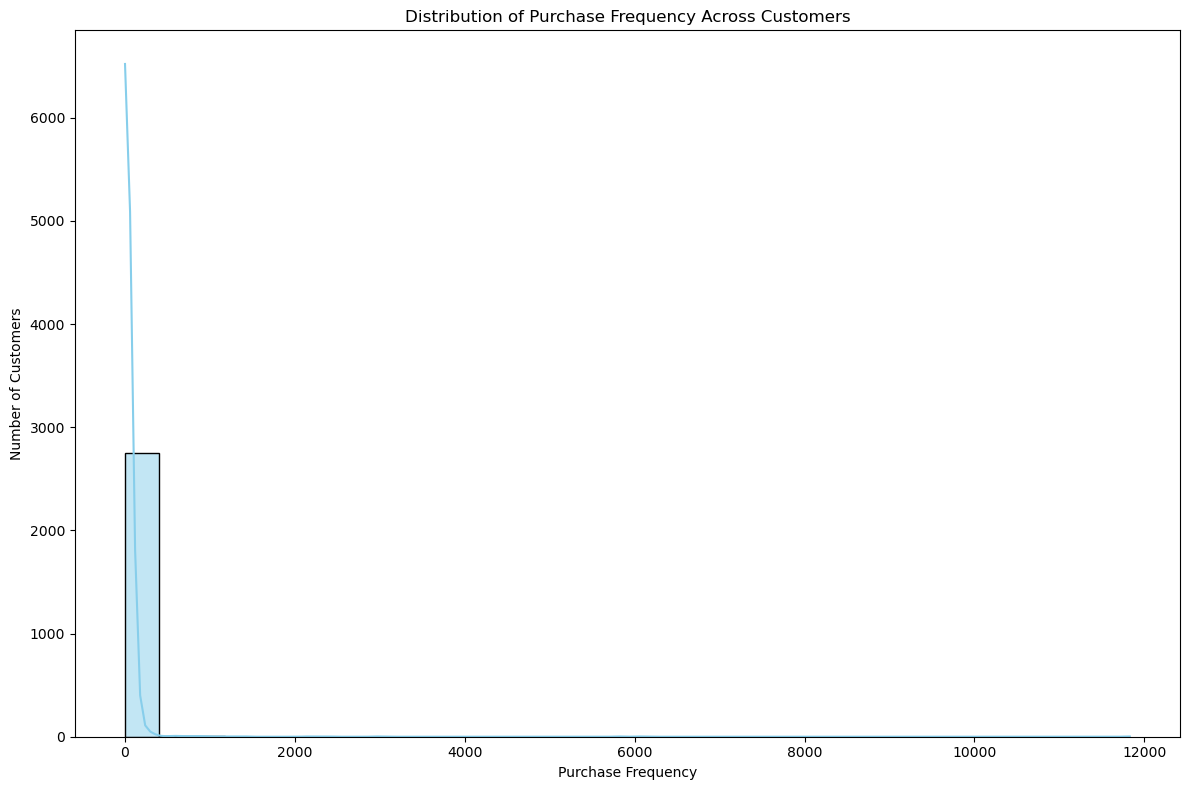

In [55]:
# Assuming purchase_freq is your DataFrame
plt.figure(figsize=(12, 8))
sns.histplot(data=purchase_freq, x='PURCHASE_FREQUENCY', bins=30, color='skyblue', kde=True)
plt.title('Distribution of Purchase Frequency Across Customers')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

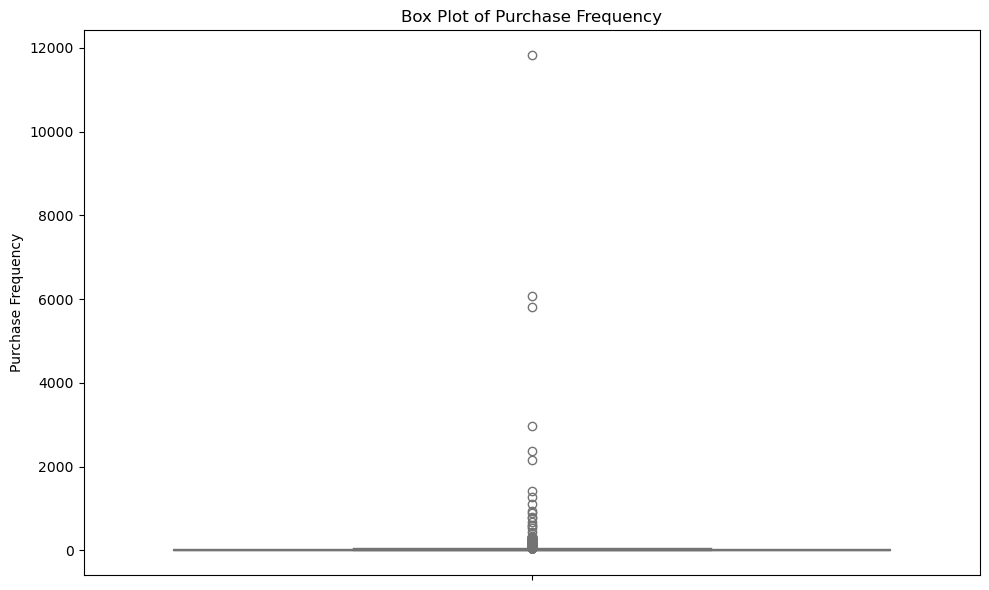

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(y='PURCHASE_FREQUENCY', data=purchase_freq, color='lightgreen')
plt.title('Box Plot of Purchase Frequency')
plt.ylabel('Purchase Frequency')
plt.tight_layout()
plt.show()

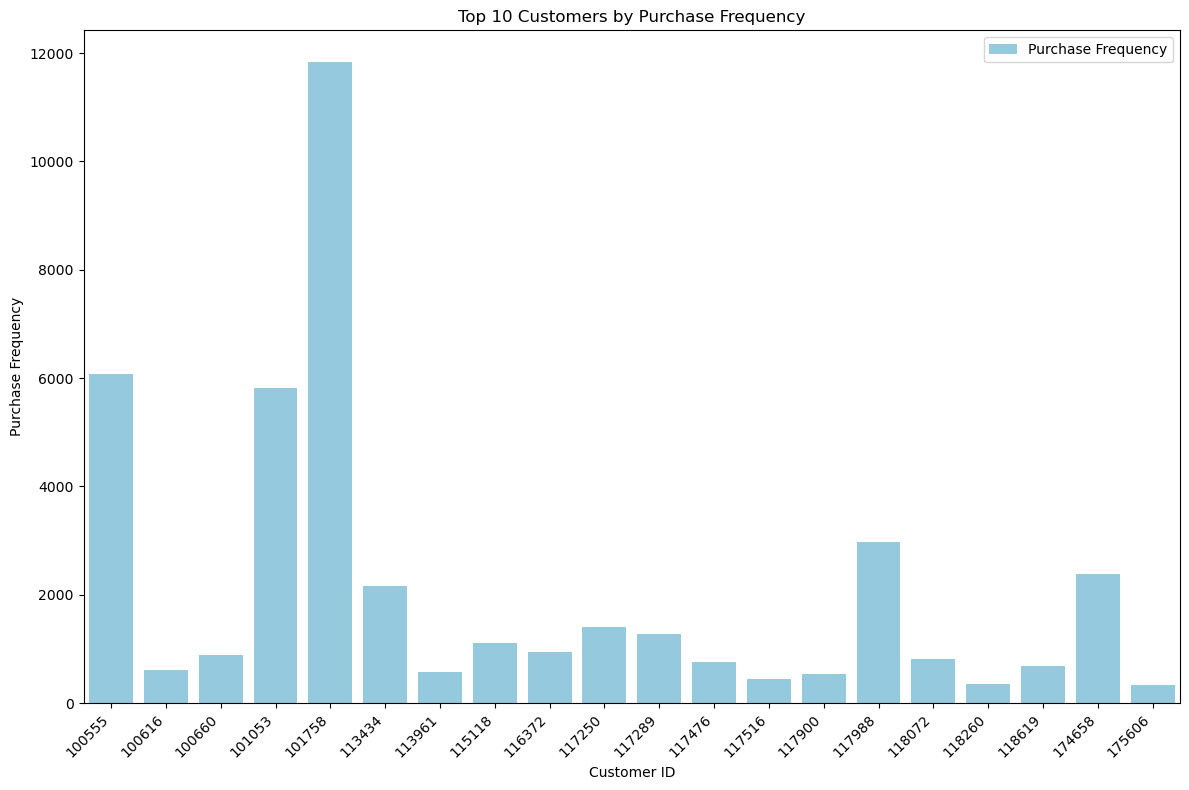

In [59]:
# Select top 10 customers by PURCHASE_FREQUENCY
top_customers = purchase_freq.nlargest(20, 'PURCHASE_FREQUENCY')

plt.figure(figsize=(12, 8))
sns.barplot(x='CUSTOMER_ID', y='PURCHASE_FREQUENCY', data=top_customers, color='skyblue', label='Purchase Frequency')
plt.title('Top 10 Customers by Purchase Frequency')
plt.xlabel('Customer ID')
plt.ylabel('Purchase Frequency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
monthly_freq

,CUSTOMER_ID,MONTH_YEAR,INVOICE_NO
0,100006,2022-01,1
1,100006,2022-03,3
2,100006,2022-08,2
3,100006,2022-10,2
4,100006,2023-01,2
...,...,...,...
27516,177469,2024-12,2
27517,177472,2024-12,1
27518,177473,2024-12,1
27519,177475,2024-12,1


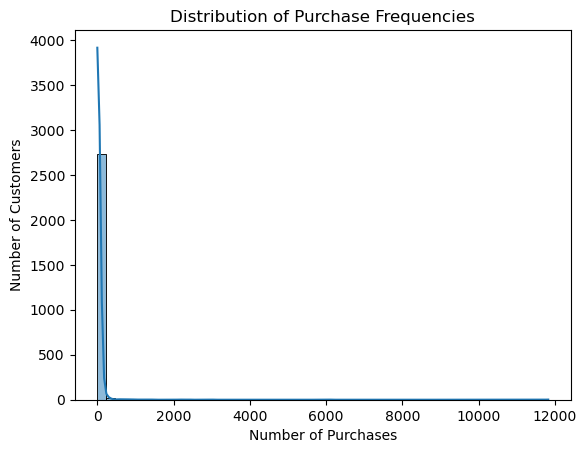

In [35]:
sns.histplot(purchase_freq['PURCHASE_FREQUENCY'], bins=50, kde=True)
plt.title('Distribution of Purchase Frequencies')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

In [36]:
top_customers = purchase_freq.sort_values('PURCHASE_FREQUENCY', ascending=False).head(10)
print(top_customers)

      CUSTOMER_ID  PURCHASE_FREQUENCY
232        101758               11829
90         100555                6071
201        101053                5821
837        117988                2980
1571       174658                2381
337        113434                2166
669        117250                1411
676        117289                1274
437        115118                1108
553        116372                 943


In [37]:
avg_freq = purchase_freq['PURCHASE_FREQUENCY'].mean()
print(f"Average purchases per customer: {avg_freq:.2f}")

Average purchases per customer: 34.50


In [38]:
repeat_customers = purchase_freq[purchase_freq['PURCHASE_FREQUENCY'] > 1]['CUSTOMER_ID'].nunique()
total_customers = purchase_freq['CUSTOMER_ID'].nunique()
repeat_rate = (repeat_customers / total_customers) * 100
print(f"Repeat customer rate: {repeat_rate:.2f}%")

Repeat customer rate: 80.65%


# Product Categories

In [63]:
product_per_type = cleaned_df.groupby('PRODUCT_TYPE')['PRODUCT_CODE'].nunique()
product_per_type

PRODUCT_TYPE
1121 - Steam Rice      21
1121 Sella              1
1121 Sella Rice         5
1509 Steamed Rice      10
Basmati Rice           90
Basmati Sella Rice     13
Beverages              44
Bran / Granules         1
Bran/Granules           3
Broken Rice             7
Brown Basmati Rice      4
COCONUT                12
Canned Food            80
Coconut                12
Easy Cook Rice         38
Fish                  167
Flour                 116
Fresh                   9
Frozen                361
Fusion Rice            11
Ingredients           266
Instant Meals          46
Jasmine Rice           13
Long Grain              1
Long Grain Rice        30
MNTC                    2
Meal Kit                2
No Group                7
Noodles/Pasta         111
Nuts & Dry Fruits      11
Oil                    13
Other                   9
Other Rice             36
Packing                22
Pulses/Beans          212
Rice                  476
STAT                    1
Sauces/Pickles        183

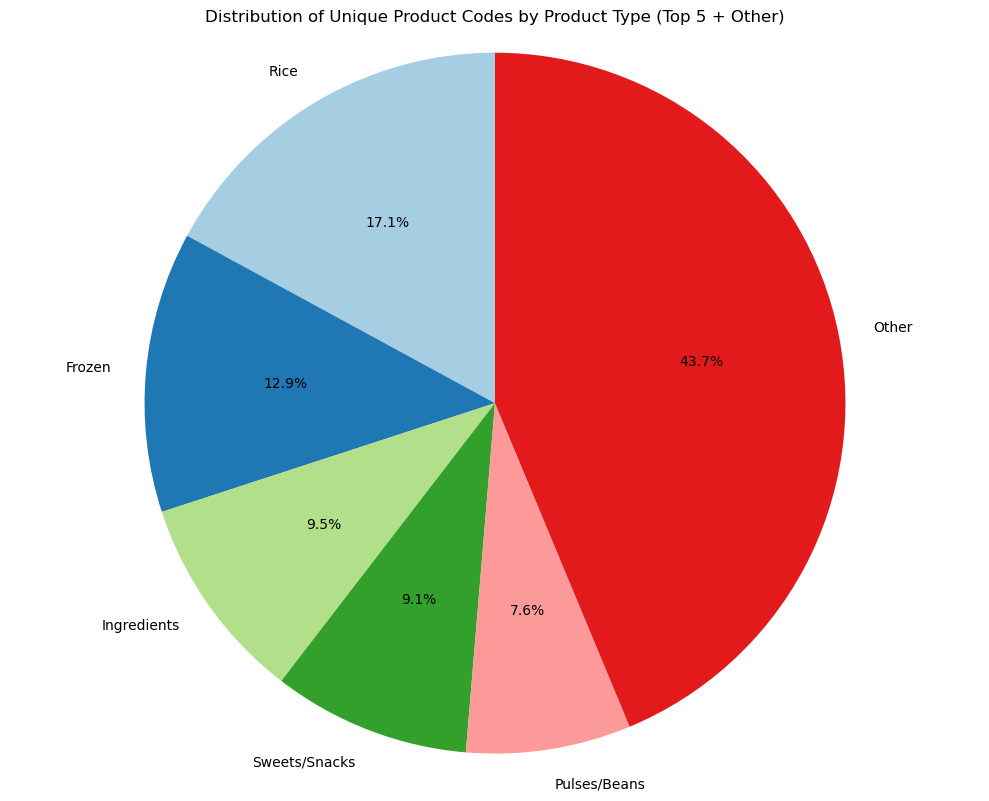

In [70]:
n_categories = 5
top_product_types = product_per_type.nlargest(n_categories)
other_count = product_per_type.sum() - top_product_types.sum()
top_product_types = pd.concat([top_product_types, pd.Series({'Other': other_count})])

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(top_product_types, labels=top_product_types.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Unique Product Codes by Product Type (Top 5 + Other)')
plt.axis('equal')  # Ensure circular shape
plt.tight_layout()
plt.show()

In [40]:
products_per_brand = cleaned_df.groupby('BRAND_NAME')['PRODUCT_CODE'].nunique().reset_index()
products_per_brand

,BRAND_NAME,PRODUCT_CODE
0,ALDI,9
1,Ajinomoto,1
2,Akira,33
3,Apna,18
4,Apollo,4
...,...,...
129,White Crystal,1
130,White Tower,2
131,Wonderfarm,2
132,YUM SENG,1


In [41]:
products_per_category = cleaned_df.groupby('PRODUCT')['PRODUCT_CODE'].nunique()
products_per_category

PRODUCT
1121 L/G          10
Ackees            12
Almonds            1
Arborio            2
Atta              36
                  ..
Vegetables         1
Vermicelli         9
WINE               1
Wafers             4
Waterchestnuts     3
Name: PRODUCT_CODE, Length: 181, dtype: int64

In [42]:
products_per_region = cleaned_df.groupby('REGION')['PRODUCT_CODE'].nunique()
products_per_region

REGION
African              148
Caribbean            317
Commodities           58
Eastern European      50
European               7
MNTC                   1
Marketing              2
Mediterranean         10
No Category            2
Oriental             277
Other                 31
Packaging              8
Polish                42
Private Label        153
Rice                   1
STAT                   1
South Asian         1480
Transportation         2
Name: PRODUCT_CODE, dtype: int64

# Total Number of Purchases (Invoices) per Customer

In [43]:
purchases_per_customer = cleaned_df.groupby(['CUSTOMER_ID', 'CUSTOMER_NAME'])['INVOICE_NO'].nunique().reset_index()
purchases_per_customer.rename(columns={'INVOICE_NO': 'TOTAL_PURCHASES'}, inplace=True)
print(purchases_per_customer.sort_values('TOTAL_PURCHASES', ascending=False))

      CUSTOMER_ID                                    CUSTOMER_NAME  \
245        101758                                 J. Sainsbury Plc   
96         100555                                  Asda Stores Ltd   
210        101053                                 Tesco Stores Ltd   
896        117988                       Lidl Great Britain Limited   
1670       174658                        Amazon EU SARL, UK BRANCH   
...           ...                                              ...   
102        100577            B&A Halal Butchers (B & A Uk Ltd T/A)   
1731       174752                                             zaha   
1730       174751                    Hen House (Wholesale) Limited   
1728       174749  Wuxi New-life Import and Export Trading Co. Ltd   
2896       177476                                          Bourhan   

      TOTAL_PURCHASES  
245             11224  
96               6071  
210              5821  
896              2980  
1670             2381  
...            

# Total Quantity Purchased per Customer

In [75]:
quantity_per_customer = cleaned_df.groupby(['CUSTOMER_ID', 'CUSTOMER_NAME'])['QUANTITY'].sum().reset_index()
print(quantity_per_customer.sort_values('QUANTITY', ascending=False))

      CUSTOMER_ID                 CUSTOMER_NAME     QUANTITY
766        117476    AB AGRI LTD T/A KW TRIDENT  12011828.98
210        101053              Tesco Stores Ltd   7757495.00
896        117988    Lidl Great Britain Limited   7595045.00
96         100555               Asda Stores Ltd   5827537.00
245        101758              J. Sainsbury Plc   5156920.00
...           ...                           ...          ...
239        101395            J.B.J. PALLETS LTD         1.00
2014       175258  Chirag Aliasger Vahora Sales         1.00
808        117659         Dubar Investments Ltd         1.00
2037       175315           SURYA SOLAR LIMITED         1.00
1797       174862       SC FILMS INTERNATIONAL         -4.00

[2897 rows x 3 columns]


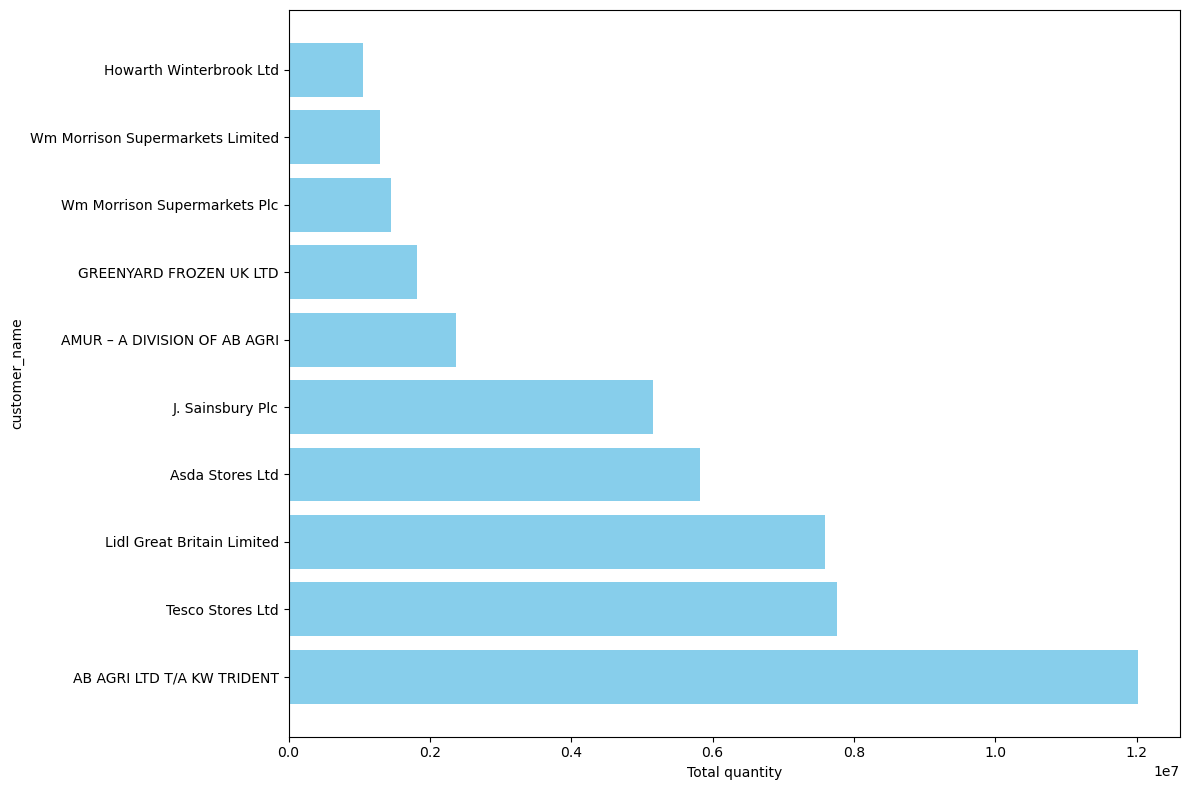

In [80]:
n_categories = 10
top_10 = quantity_per_customer.nlargest(n_categories,'QUANTITY')
plt.figure(figsize=(12,8))
plt.barh(top_10['CUSTOMER_NAME'],top_10['QUANTITY'],color = 'skyblue')
plt.xlabel('Total quantity')
plt.ylabel('customer_name')
plt.tight_layout()
plt.show()

# Total Spending (Net Value) per Customer

In [85]:
spending_per_customer = cleaned_df.groupby(['CUSTOMER_ID', 'CUSTOMER_NAME'])['NETT_VALUE'].sum().reset_index()
print(spending_per_customer.sort_values('NETT_VALUE', ascending=False))

      CUSTOMER_ID                     CUSTOMER_NAME   NETT_VALUE
210        101053                  Tesco Stores Ltd  81613753.90
896        117988        Lidl Great Britain Limited  72375246.75
96         100555                   Asda Stores Ltd  68209694.34
245        101758                  J. Sainsbury Plc  42113453.42
355        113434  Wm Morrison Supermarkets Limited  12868853.48
...           ...                               ...          ...
2287       175733    All-fill International Limited        76.79
1909       175070        Fresh Direct/Fresh Kitchen        76.32
2666       176940                      Tritech litd        68.60
2854       177358                          B A Noor        41.90
1009       118326       Snacks Factory -Surya Foods         0.00

[2897 rows x 3 columns]


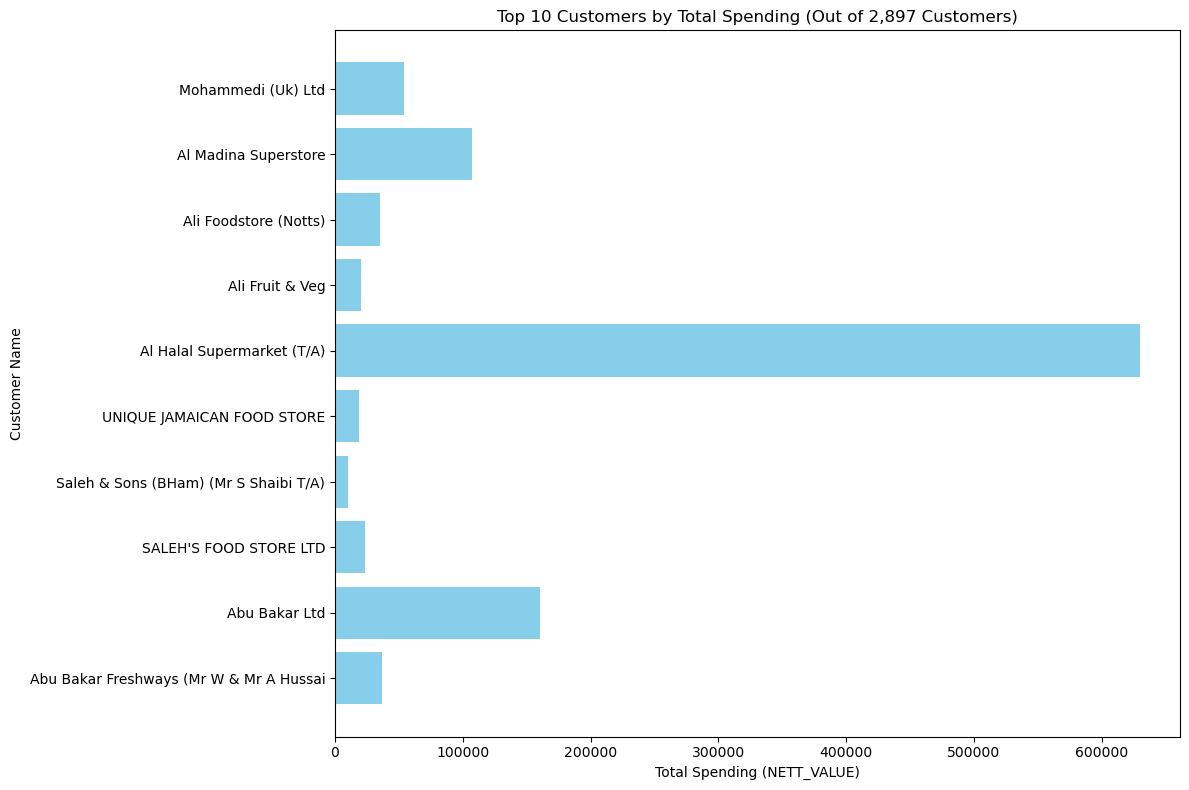

In [86]:
n_categories = 10
top_10_spending = spending_per_customer.head(n_categories)

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_10_spending['CUSTOMER_NAME'], top_10_spending['NETT_VALUE'], color='skyblue')
plt.xlabel('Total Spending (NETT_VALUE)')
plt.ylabel('Customer Name')
plt.title(f'Top {n_categories} Customers by Total Spending (Out of 2,897 Customers)')
plt.tight_layout()

# Average Purchase Value per Customer

In [88]:
avg_purchase_value = cleaned_df.groupby(['CUSTOMER_ID', 'CUSTOMER_NAME'])['NETT_VALUE'].mean().reset_index()
print(avg_purchase_value.sort_values('NETT_VALUE', ascending=False))

      CUSTOMER_ID                 CUSTOMER_NAME    NETT_VALUE
2802       177241       ADSCO International Ltd  56980.000000
1303       173789   Forrest Fresh Foods Limited  50485.833333
2014       175258  Chirag Aliasger Vahora Sales  50000.000000
576        116172            Giro Foods Ltd - D  48101.422817
1785       174844       FGS INGREDIENTS LIMITED  43673.640000
...           ...                           ...           ...
2020       175268                 Express Store      9.692639
2658       176923                   FBANADZ LTD      8.830000
2854       177358                      B A Noor      6.983333
465        115118                       Samples      0.655713
1009       118326   Snacks Factory -Surya Foods      0.000000

[2897 rows x 3 columns]


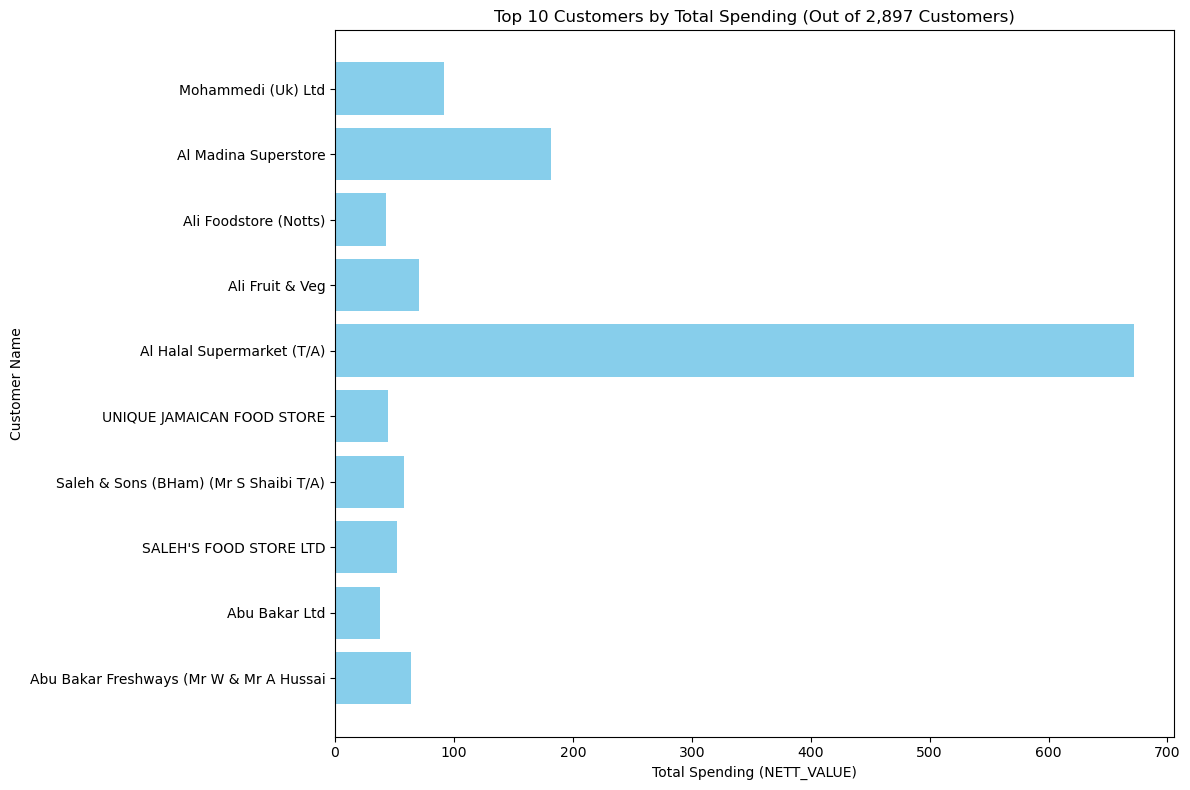

In [89]:
n_categories = 10
top_10_spending = avg_purchase_value.head(n_categories)

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(top_10_spending['CUSTOMER_NAME'], top_10_spending['NETT_VALUE'], color='skyblue')
plt.xlabel('Total Spending (NETT_VALUE)')
plt.ylabel('Customer Name')
plt.title(f'Top {n_categories} Customers by Total Spending (Out of 2,897 Customers)')
plt.tight_layout()

#  Number of Unique Products Purchased per Customer

In [47]:
unique_products_per_customer = cleaned_df.groupby(['CUSTOMER_ID', 'CUSTOMER_NAME'])['PRODUCT_CODE'].nunique().reset_index()
print(unique_products_per_customer.sort_values('PRODUCT_CODE', ascending=False))

      CUSTOMER_ID                           CUSTOMER_NAME  PRODUCT_CODE
465        115118                                 Samples          1072
967        118186                     Falcon (EM) Limited           904
531        115803  INVENTURE COVENTRY LTD T/A OPUS FOODS            780
227        101098         Worldwide Foods (Cheetham Hill)           769
99         100559                  Asian Cash & Carry Ltd           733
...           ...                                     ...           ...
2369       175918               Bismillah Supermarket Ltd             1
1277       173738                         Mancunian Foods             1
2050       175349                            Pretty Nails             1
1470       174316                                   Prime             1
1850       174955                   Elysium Solar Limited             1

[2897 rows x 3 columns]


# RFM Analysis (Recency, Frequency, Monetary)

In [82]:
from datetime import datetime

current_date = datetime.now()

rfm = cleaned_df.groupby('CUSTOMER_ID').agg({
    'INV_CREATED_DATE': lambda x: (current_date - x.max()).days,  # Recency (days since last purchase)
    'INVOICE_NO': 'nunique',  # Frequency (number of purchases)
    'NETT_VALUE': 'sum'       # Monetary (total spending)
}).rename(columns={
    'INV_CREATED_DATE': 'Recency',
    'INVOICE_NO': 'Frequency',
    'NETT_VALUE': 'Monetary'
})

print(rfm.sort_values('Monetary', ascending=False))

             Recency  Frequency     Monetary
CUSTOMER_ID                                 
101053           140       5821  81613753.90
117988           140       2980  72375246.75
100555           140       6071  68209694.34
101758           140      11829  44740038.58
113434           141       2166  23661176.76
...              ...        ...          ...
175733           545          1        76.79
175070           627          1        76.32
176940           397          1        68.60
177358           188          1        41.90
118326           873         18         0.00

[2765 rows x 3 columns]


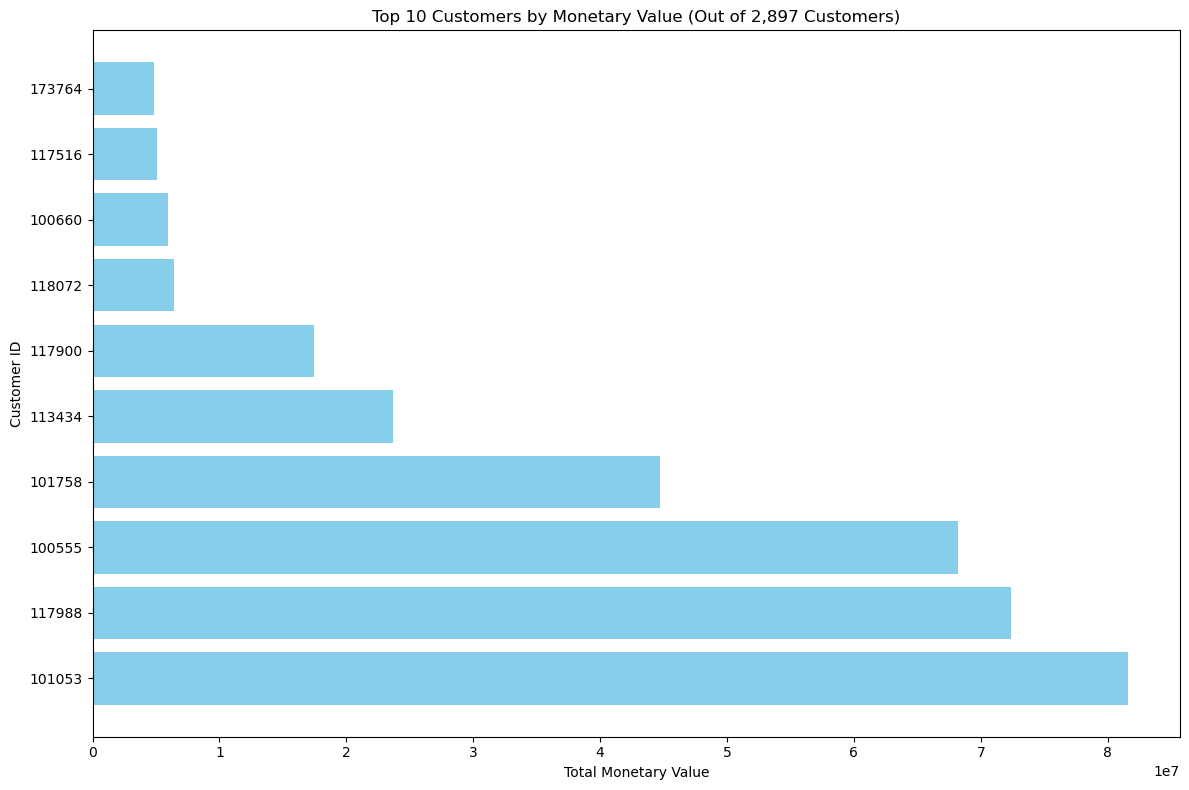

In [83]:
n_categories = 10
top_10_rfm = rfm.sort_values('Monetary', ascending=False).head(n_categories)

# Create horizontal bar chart for Monetary
plt.figure(figsize=(12, 8))
plt.barh(top_10_rfm.index.astype(str), top_10_rfm['Monetary'], color='skyblue')
plt.xlabel('Total Monetary Value')
plt.ylabel('Customer ID')
plt.title(f'Top {n_categories} Customers by Monetary Value (Out of 2,897 Customers)')
plt.tight_layout()

# Models

### Logistic Regression

In [49]:
data = cleaned_df[['ID','CUSTOMER_ID','PRODUCT_CODE','BRAND_ID','Repetitive_Customer','Repetitive_Within_30_Days']]
data.head()

,ID,CUSTOMER_ID,PRODUCT_CODE,BRAND_ID,Repetitive_Customer,Repetitive_Within_30_Days
0,3348131,100006,11555.0,317.0,True,True
1,3348132,100006,13300.0,536.0,True,True
2,3348133,100006,16911.0,164.0,True,True
3,3348169,100006,25950.0,21.0,True,True
4,3348206,100006,27038.0,615.0,True,True


In [50]:
merged_df = pd.merge(data, rfm, on='CUSTOMER_ID', how='left')

In [51]:
megred_df = pd.merge(merged_df, monthly_freq, on = 'CUSTOMER_ID', how = 'left')

In [58]:
df.to_csv('merged_df.csv',index=False)

In [151]:
merged_df.shape

(803095, 9)

In [152]:
x = merged_df.drop(['Repetitive_Customer'],axis = 1)
y = np.asarray(merged_df['Repetitive_Customer'])

In [153]:
x.isna().sum()

ID                              0
CUSTOMER_ID                     0
PRODUCT_CODE                 1798
BRAND_ID                     1798
Repetitive_Within_30_Days       0
Recency                         0
Frequency                       0
Monetary                        0
dtype: int64

In [154]:
x['PRODUCT_CODE'] = x['PRODUCT_CODE'].fillna(x['PRODUCT_CODE'].mean())
x['BRAND_ID'] = x['BRAND_ID'].fillna(x['BRAND_ID'].mean())

In [155]:
np.unique(y)


array([False,  True])

In [156]:
x = StandardScaler().fit(x).transform(x)
x[0:5]

array([[-1.71698627, -0.88348635, -2.32845431, -0.50106512,  0.01739744,
        -0.15017011, -0.42524247, -0.44095635],
       [-1.71698218, -0.88348635, -1.98195948,  0.51859295,  0.01739744,
        -0.15017011, -0.42524247, -0.44095635],
       [-1.71697809, -0.88348635, -1.26494355, -1.21342897,  0.01739744,
        -0.15017011, -0.42524247, -0.44095635],
       [-1.71683074, -0.88348635,  0.52987978, -1.8792331 ,  0.01739744,
        -0.15017011, -0.42524247, -0.44095635],
       [-1.7166793 , -0.88348635,  0.74591782,  0.88641481,  0.01739744,
        -0.15017011, -0.42524247, -0.44095635]])

In [157]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)

In [158]:
lr = LogisticRegression(random_state = 42)

In [159]:
lr.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [161]:
print("ROC AUC Score:", roc_auc_score(y_test, lr.predict_proba(x_test)[:, 1]))

ROC AUC Score: 0.9797242830827894


In [162]:
predictions = lr.predict(x_test)
predictions

array([ True,  True,  True, ...,  True,  True,  True])

In [163]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.987261780984815


In [164]:
print(confusion_matrix(y_test, predictions))

[[   588   1701]
 [   345 157985]]


In [165]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

       False       0.63      0.26      0.36      2289
        True       0.99      1.00      0.99    158330

    accuracy                           0.99    160619
   macro avg       0.81      0.63      0.68    160619
weighted avg       0.98      0.99      0.98    160619



In [40]:
# Example groupby for features
customer_features = df[df['order_year'] < 2025].groupby('CUSTOMER_ACCOUNT_CODE').agg({
    'INV_QTY': ['sum', 'mean'],
    'INV_NETT_VALUE': ['sum', 'mean'],
    'GROSS_PROFIT': 'sum',
    'order_year': ['nunique'],  # purchasing spread
    'ID': 'count',  # number of orders
}).reset_index()

# Flatten columns
customer_features.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in customer_features.columns]


In [41]:
customer_features

,CUSTOMER_ACCOUNT_CODE_,INV_QTY_sum,INV_QTY_mean,INV_NETT_VALUE_sum,INV_NETT_VALUE_mean,GROSS_PROFIT_sum,order_year_nunique,ID_count
0,100006,2997.0,5.267135,36512.10,64.168893,6847.760,3,569
1,100007,15337.0,3.600235,160425.86,37.658653,37422.908,3,4260
2,100011,3137.0,5.019200,33532.56,53.652096,7255.560,3,625
3,100022,1731.0,4.131265,18569.36,44.318282,3702.700,3,419
4,100024,37374.0,39.886873,629883.98,672.234771,60373.080,3,937
...,...,...,...,...,...,...,...,...
2760,177469,225.0,7.031250,3745.39,117.043437,955.200,1,32
2761,177472,32.0,32.000000,351.68,351.680000,89.280,1,1
2762,177473,36.0,6.000000,608.75,101.458333,71.200,1,6
2763,177475,15.0,1.250000,280.96,23.413333,107.140,1,12


# Random Forest

In [73]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer

In [100]:
data = cleaned_df[['ID','CUSTOMER_ID','PRODUCT_CODE','BRAND_ID','Repetitive_Customer','Repetitive_Within_30_Days']]
data.head()

,ID,CUSTOMER_ID,PRODUCT_CODE,BRAND_ID,Repetitive_Customer,Repetitive_Within_30_Days
0,3348131,100006,11555.0,317.0,True,True
1,3348132,100006,13300.0,536.0,True,True
2,3348133,100006,16911.0,164.0,True,True
3,3348169,100006,25950.0,21.0,True,True
4,3348206,100006,27038.0,615.0,True,True


In [101]:
x = data.drop(['Repetitive_Customer'],axis = 1)
y = np.asarray(data['Repetitive_Customer'])

In [102]:
cat_imputer = SimpleImputer(strategy = 'most_frequent')
x[['PRODUCT_CODE','BRAND_ID']] = cat_imputer.fit_transform(x[['PRODUCT_CODE','BRAND_ID']])

In [103]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [104]:
model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    min_samples_split = 50,
    n_jobs = -1,
    random_state = 42
)

In [105]:
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, min_samples_split=50, n_jobs=-1,
                       random_state=42)

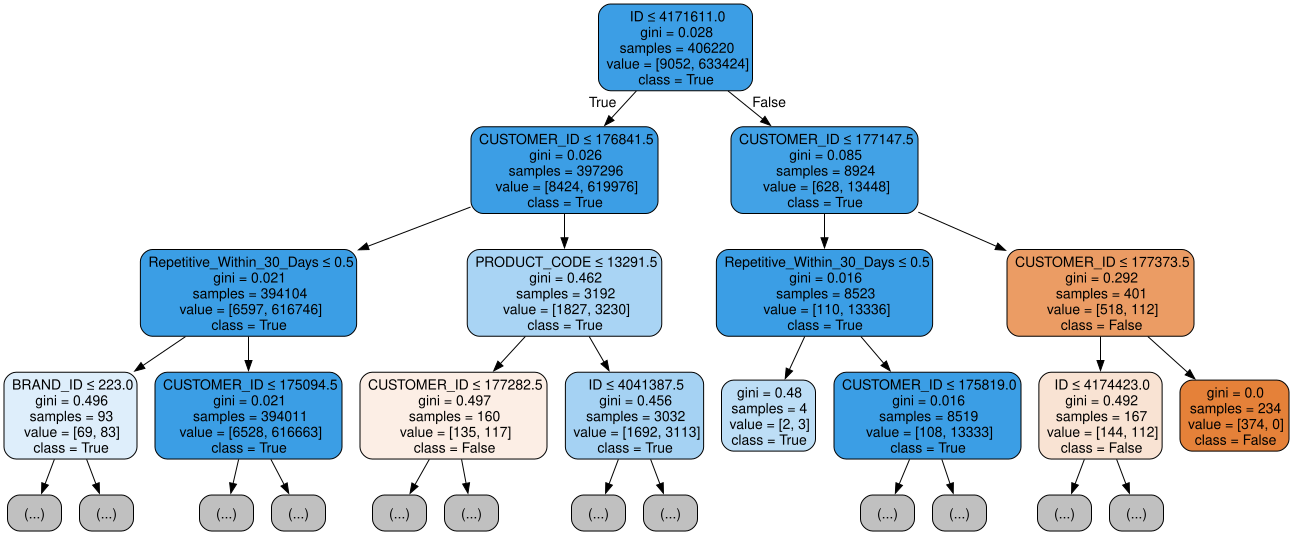

In [108]:
from sklearn.tree import export_graphviz
import graphviz

# Assuming you have a trained Random Forest model (rf_model)
# Replace 'rf_model' with your actual model variable
dot_data = export_graphviz(
    model.estimators_[0],  # First tree in the Random Forest
    out_file=None,
    feature_names=['ID', 'CUSTOMER_ID', 'PRODUCT_CODE', 'BRAND_ID','Repetitive_Within_30_Days'],  # Corrected parameter name
    class_names=['False', 'True'],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3  # Limit depth for readability
)

# Render the tree
graph = graphviz.Source(dot_data)
#graph.render("full_tree", format='pdf', cleanup=True)
graph.render("random_forest_tree", format='png')  # Saves as PNG
graph  # Display in Jupyter Notebook

In [109]:
y_pred = model.predict(x_test)
y_pred

array([ True,  True,  True, ...,  True,  True,  True])

In [110]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9885131895977437


In [112]:
y_probs = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test,y_probs)
print(f"Auc_Roc_Score, {auc_score:.4f}")

Auc_Roc_Score, 0.9719


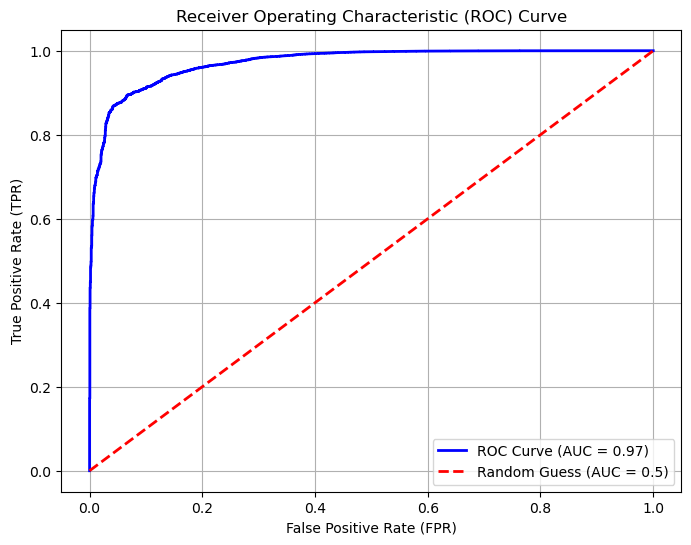

In [113]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Random Guess Line is Crucialbecause any curve above it indicates Discriminative Power

In [114]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9885131895977437


In [115]:
print(confusion_matrix(y_test, y_pred))

[[   542   1825]
 [    20 158232]]


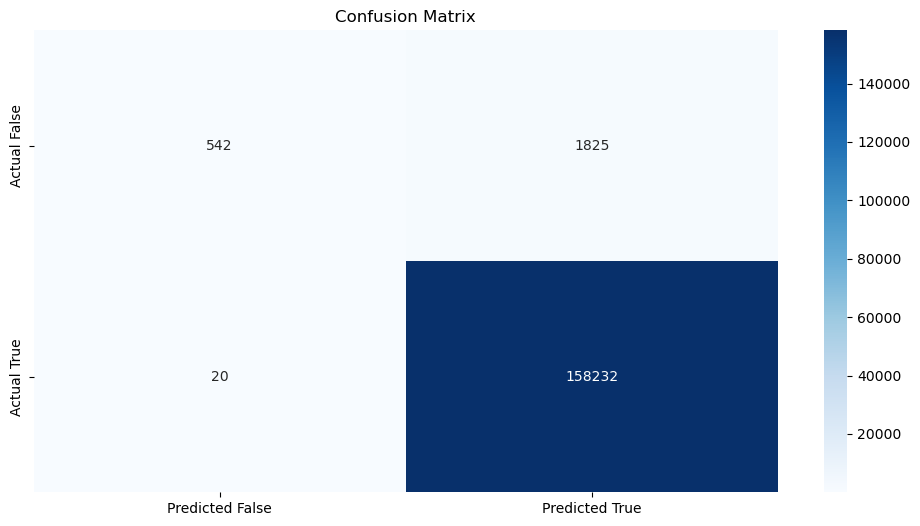

In [116]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted False', 'Predicted True'], 
            yticklabels=['Actual False', 'Actual True'])
plt.title('Confusion Matrix')
plt.show()

In [117]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(x_test)[:, 1]))

              precision    recall  f1-score   support

       False       0.96      0.23      0.37      2367
        True       0.99      1.00      0.99    158252

    accuracy                           0.99    160619
   macro avg       0.98      0.61      0.68    160619
weighted avg       0.99      0.99      0.99    160619

ROC-AUC Score: 0.9718620532186976


In [118]:
predictions_series = pd.Series(y_pred, name='Predicted_Repetitive_Customer')

# Reset index just to be safe
x_test_reset = x_test.reset_index(drop=True)
predictions_series_reset = predictions_series.reset_index(drop=True)

# Combine with customer info
result_df = pd.concat([x_test_reset[['CUSTOMER_ID']], predictions_series_reset], axis=1)


In [119]:
result_df

,CUSTOMER_ID,Predicted_Repetitive_Customer
0,117988,True
1,115838,True
2,100739,True
3,100804,True
4,117759,True
...,...,...
160614,174888,True
160615,177469,False
160616,112892,True
160617,117988,True


In [120]:
result_df['Predicted_Repetitive_Customer'].value_counts(normalize=True)

Predicted_Repetitive_Customer
True     0.996501
False    0.003499
Name: proportion, dtype: float64

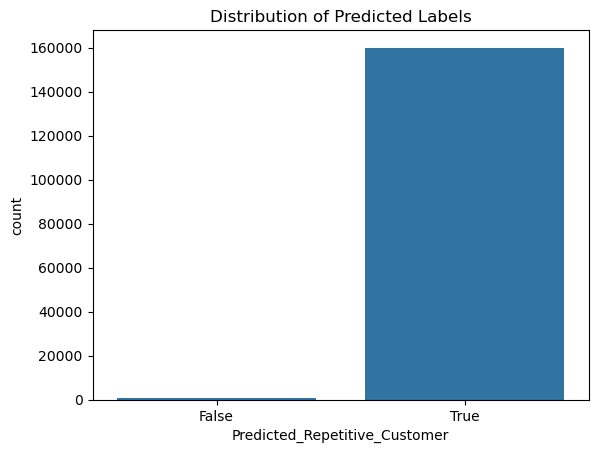

In [98]:
sns.countplot(data=result_df, x='Predicted_Repetitive_Customer')
plt.title('Distribution of Predicted Labels')
plt.show()

# Random Forest with new parameters

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [51]:
data = cleaned_df[['ID','CUSTOMER_ID','PRODUCT_CODE','BRAND_ID','Repetitive_Customer','Repetitive_Within_30_Days']]
data.head()

,ID,CUSTOMER_ID,PRODUCT_CODE,BRAND_ID,Repetitive_Customer,Repetitive_Within_30_Days
0,3348131,100006,11555.0,317.0,True,True
1,3348132,100006,13300.0,536.0,True,True
2,3348133,100006,16911.0,164.0,True,True
3,3348169,100006,25950.0,21.0,True,True
4,3348206,100006,27038.0,615.0,True,True


In [52]:
merged_df = pd.merge(data, rfm, on='CUSTOMER_ID', how='left')

In [53]:
merged_df.columns

Index(['ID', 'CUSTOMER_ID', 'PRODUCT_CODE', 'BRAND_ID', 'Repetitive_Customer',
       'Repetitive_Within_30_Days', 'Recency', 'Frequency', 'Monetary'],
      dtype='object')

In [54]:
merged_df.columns

Index(['ID', 'CUSTOMER_ID', 'PRODUCT_CODE', 'BRAND_ID', 'Repetitive_Customer',
       'Repetitive_Within_30_Days', 'Recency', 'Frequency', 'Monetary'],
      dtype='object')

In [55]:
corr_matrix = merged_df.corr()

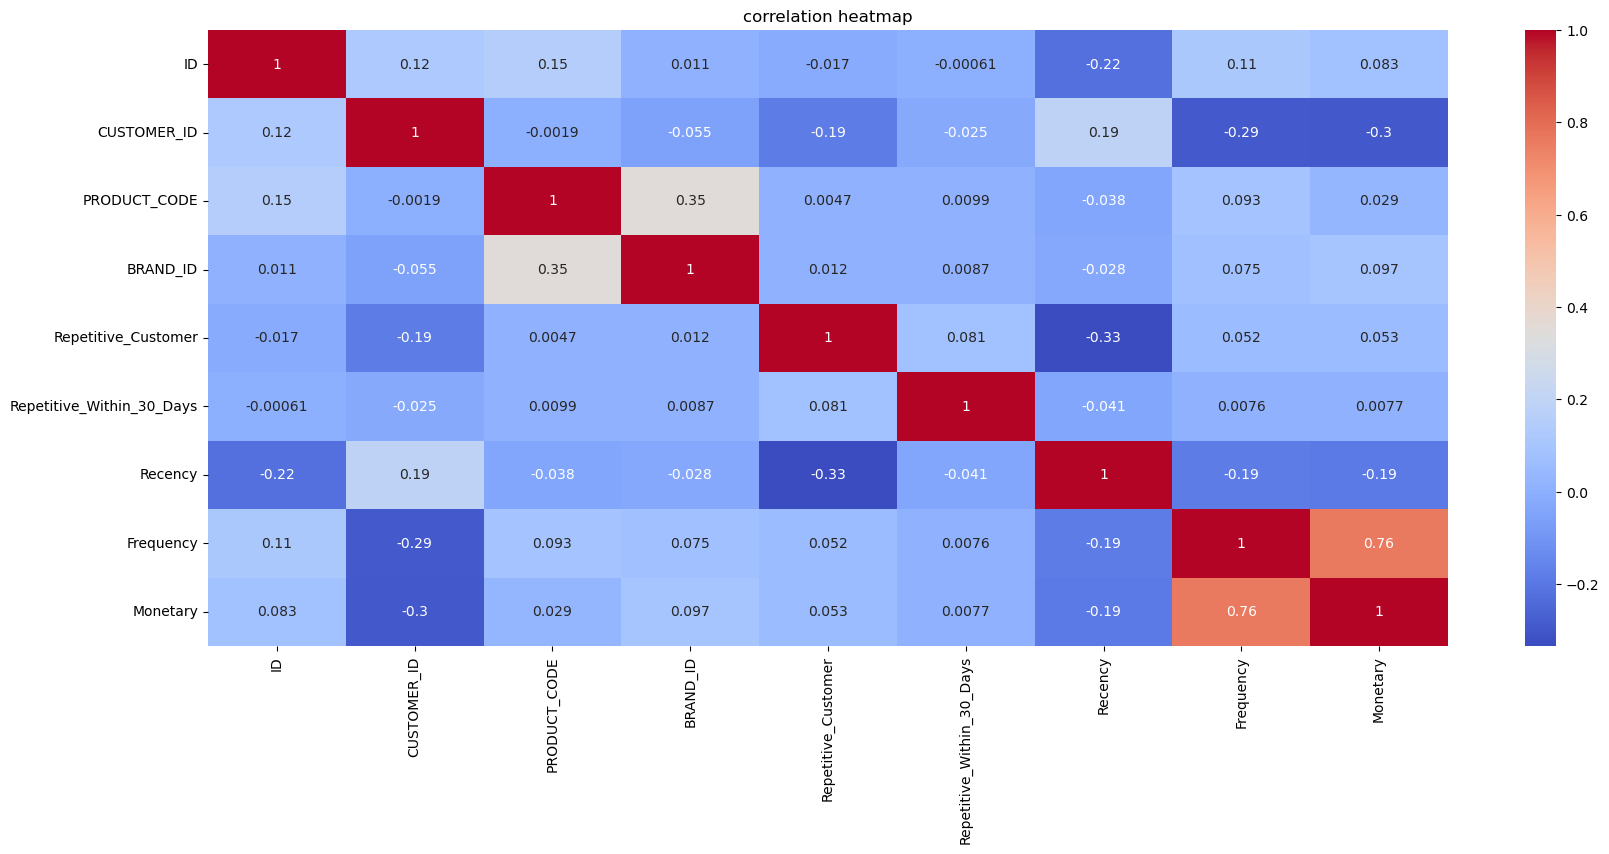

In [56]:
plt.figure(figsize=(20,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.title("correlation heatmap")
plt.show()

In [57]:
merged_df['average_monetary_per_purchase'] = merged_df['Monetary']/merged_df['Frequency']

In [58]:
merged_df.head()

,ID,CUSTOMER_ID,PRODUCT_CODE,BRAND_ID,Repetitive_Customer,Repetitive_Within_30_Days,Recency,Frequency,Monetary,average_monetary_per_purchase
0,3348131,100006,11555.0,317.0,True,True,177,29,36512.1,1259.037931
1,3348132,100006,13300.0,536.0,True,True,177,29,36512.1,1259.037931
2,3348133,100006,16911.0,164.0,True,True,177,29,36512.1,1259.037931
3,3348169,100006,25950.0,21.0,True,True,177,29,36512.1,1259.037931
4,3348206,100006,27038.0,615.0,True,True,177,29,36512.1,1259.037931


In [59]:
x = merged_df.drop(columns = ['Repetitive_Customer'],axis=1)
y = merged_df['Repetitive_Customer']

In [60]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')  # or 'median'
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

In [62]:
scaler = StandardScaler()
#numeric_cols = ['Recency','Frequency','Monetary','average_monetary_per_purchase']
#x[numeric_cols] = scaler.fit_transform(x[numeric_cols])

In [63]:
x= scaler.fit_transform(x)

In [64]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size = 0.2, stratify = y)

In [65]:
print(y.value_counts(normalize = True))

Repetitive_Customer
True     0.985748
False    0.014252
Name: proportion, dtype: float64


In [91]:
# Repetitive customer is still imbalanced so applying smote technique

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)
x_train,y_train = smote.fit_resample(x_train,y_train)

In [67]:
print(y_train.value_counts(normalize = True))

Repetitive_Customer
True     0.5
False    0.5
Name: proportion, dtype: float64


In [68]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [71]:
model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    min_samples_split = 50,
    n_jobs = -1,
    random_state = 42
)
#model = RandomForestClassifier(n_estimators = 100,random_state = 42)
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=50, n_jobs=-1,
                       random_state=42)

In [72]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(x_test)[:, 1]))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      2289
        True       1.00      1.00      1.00    158330

    accuracy                           1.00    160619
   macro avg       1.00      1.00      1.00    160619
weighted avg       1.00      1.00      1.00    160619

ROC-AUC Score: 0.9999999255002596
